-------------------------------------
# **YLIVERTAINEN Bad Data Craniotomy**
-------------------------------------

----------------------
## ⚙️ **SETUP for Greatness** ⚙️
----------------------

In [1]:
from pathlib import Path
import sys
def find_root(marker: str = "predictive.py") -> Path:
    p = Path.cwd().resolve()
    for folder in [p, *p.parents]:
        if (folder / marker).is_file():
            return folder
    raise FileNotFoundError(f"Could not find {marker} above {p}")
root = find_root() # Path to .../ylivertainen
print("Current location:", root.name)
print(root)
repo_root = root.parent  # .../TheLibraryOfCode
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print("Inserted (times):", sys.path.count(str(root)))
print("Current location:", repo_root.name)

Current location: ylivertainen
C:\dev\TheLibraryOfCode\YlivertainenBadDataCraniotomy\ylivertainen
Inserted (times): 0
Current location: YlivertainenBadDataCraniotomy


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
#======================= IMPORT LIBRARIES ========================
#from ylivertainen.aesthetics_helpers import GREEN, YELLOW, ORANGE, RED, BOLD, BLUE, GRAY, RESET
import pandas as pd
from IPython.display import display, Markdown

#=======================🧹 DATA CLEANING 🧹========================
from ylivertainen.cleaning import pre_merge_check
from ylivertainen.cleaning import YlivertainenDataCleaningSurg

#=======================🚧 COHORT 🚧========================
from ylivertainen.config import big_beautiful_print
from ylivertainen.cohort import build_stroke_agreement_cohort

#=======================🙊 DDA 🙊========================
from ylivertainen.dda import YlivertainenDDA

#=======================🎨 EDA 🎨========================
from ylivertainen.eda import YlivertainenEDA

#=======================🔮 PREDICTIVE 🔮========================
from ylivertainen.predictive import build_model_frame, export_model_frame

----------------------
# 🧹🧹🧹 **YLIVERTAINEN DATASURG** 🧹🧹🧹
----------------------

## **SETUP**

### Input CSVs

In [4]:
raw_dir = root / "data" / "raw"
csvs = sorted(raw_dir.glob("*.csv"))    # <== takes all CSVs from ylivertainen/data/raw

### Do a pre-merge check
1. column name differences
2. which columns do we need

In [5]:
pre_merge_check(csvs)

======== C:\dev\TheLibraryOfCode\YlivertainenBadDataCraniotomy\ylivertainen\data\raw\testtable_synthetic.csv ========
Columns: ['Izsaukuma laiks', 'Pacienta vecums, gadi', 'Dzimums, 1 - sieviete, 2- vīrietis', 'Unnamed: 3', 'NMP pamata diagnoze: G45.9 -1; I64 - 2; I63.9 - 3', 'Nogādāšanas laiks PSKUS', 'GKS skala, 1 - nav izvērtēts', 'FastTest skala: N Negatīvs - 1; P>60 Pozitīvs, lielo asinsvadu oklūzijas iespējamība ≥ 60% - 2; P<15 Pozitīvs, lielo asinsvadu oklūzijas iespējamība <15% - 3; P>30 Pozitīvs, lielo asinsvadu oklūzijas iespējamība ap 30% - 4; nav izvērtēts - 5', 'Uzņemšanas rezultāts', 'Pārvests uz', 'Karte', 'Iestāšanās diagnoze', 'Iestāšanās diagnozes nosaukums', 'Izrakstīšanas diagnoze', 'Izrakstīšanas diagnozes nosaukums', 'Iestāšanās laiks', 'Izrakstīšanas laiks', 'Izr_dat', 'Izr_mēn', 'Izr_gads', 'Izr_kustība', 'Izr_kustības nosaukums', 'Izr_nodaļa', 'Izr_nodaļas nosaukums', 'Izr_profils', 'Izr_profila nosaukums', 'synthetic_surnames']
✅ Using this file as column name

,Izsaukuma laiks,"Pacienta vecums, gadi","Dzimums, 1 - sieviete, 2- vīrietis",Unnamed: 3,NMP pamata diagnoze: G45.9 -1; I64 - 2; I63.9 - 3,Nogādāšanas laiks PSKUS,"GKS skala, 1 - nav izvērtēts","FastTest skala: N Negatīvs - 1; P>60 Pozitīvs, lielo asinsvadu oklūzijas iespējamība ≥ 60% - 2; P<15 Pozitīvs, lielo asinsvadu oklūzijas iespējamība <15% - 3; P>30 Pozitīvs, lielo asinsvadu oklūzijas iespējamība ap 30% - 4; nav izvērtēts - 5",Uzņemšanas rezultāts,Pārvests uz,Karte,Iestāšanās diagnoze,Iestāšanās diagnozes nosaukums,Izrakstīšanas diagnoze,Izrakstīšanas diagnozes nosaukums,Iestāšanās laiks,Izrakstīšanas laiks,Izr_dat,Izr_mēn,Izr_gads,Izr_kustība,Izr_kustības nosaukums,Izr_nodaļa,Izr_nodaļas nosaukums,Izr_profils,Izr_profila nosaukums,synthetic_surnames
0,11.06.2024 03:18,69,1,NaN,2,2024-06-11 04:02:00,3,2,Hospitalized,Neurology,K202400001,I64,"Stroke, not specified as hemorrhage or infarction",J18.9,"Pneumonia, unspecified organism",2024-06-11 04:39:00,2024-06-12 01:39:00,12,6,2024,2,Transferred to another hospital,202,Stroke unit,30,Internal medicine,CerebralChaos
1,2025-06-10 16:03:00,70,1,NaN,1,2025-06-10 17:19:00,15,5,Hospitalized,Neurology,K202500002,G45.9,"Transient cerebral ischemic attack, unspecified",G45.9,"Transient cerebral ischemic attack, unspecified",2025-06-10 17:40:00,18.06.2025 19:40,18,6,2025,1,Discharged home,202,Stroke unit,30,Internal medicine,CTScanner


### Write the **[COLUMN_RENAME_MAP](../columns_to_canonical.py)**

- unified column renaming
- drops columns that are not specified
- DOES NOT create columns

### Pass CSVs into the **DataCleaningSurg**

In [6]:
project = YlivertainenDataCleaningSurg(csvs)
print(project)
display(project.df.head())

## 🧩 MERGE SUMMARY
---
**Rows:** `500`  |  **Columns:** `12`

## 🧱 CANONICAL COLUMNS
`nmpd_diag`, `izrakstisanas_diag`, `vecums`, `dzimums`, `GKS`, `FastTest`
`izsaukuma_laiks`, `nogadasana_PSKUS_laiks`, `iestasanas_laiks`, `izrakstisanas_laiks`, `discharged_how`, `patient_card_no`

---
## 🗑️ REMOVED COLUMNS

**testtable_synthetic.csv** (15)
- Iestāšanās diagnoze
- Iestāšanās diagnozes nosaukums
- Izr_dat
- Izr_gads
- Izr_kustība
- Izr_mēn
- Izr_nodaļa
- Izr_nodaļas nosaukums
- Izr_profila nosaukums
- Izr_profils
- Izrakstīšanas diagnozes nosaukums
- Pārvests uz
- Unnamed: 3
- Uzņemšanas rezultāts
- synthetic_surnames


---
## 🔁 RENAMED COLUMNS

FastTest
- FastTest skala: N Negatīvs - 1; P>60 Pozitīvs, lielo asinsvadu oklūzijas iespējamība ≥ 60% - 2; P<15 Pozitīvs, lielo asinsvadu oklūzijas iespējamība <15% - 3; P>30 Pozitīvs, lielo asinsvadu oklūzijas iespējamība ap 30% - 4; nav izvērtēts - 5 (testtable_synthetic.csv)

GKS
- GKS skala, 1 - nav izvērtēts (testtable_synthetic.csv)

discharged_how
- Izr_kustības nosaukums (testtable_synthetic.csv)

dzimums
- Dzimums, 1 - sieviete, 2- vīrietis (testtable_synthetic.csv)

iestasanas_laiks
- Iestāšanās laiks (testtable_synthetic.csv)

izrakstisanas_diag
- Izrakstīšanas diagnoze (testtable_synthetic.csv)

izrakstisanas_laiks
- Izrakstīšanas laiks (testtable_synthetic.csv)

izsaukuma_laiks
- Izsaukuma laiks (testtable_synthetic.csv)

nmpd_diag
- NMP pamata diagnoze: G45.9 -1; I64 - 2; I63.9 - 3 (testtable_synthetic.csv)

nogadasana_PSKUS_laiks
- Nogādāšanas laiks PSKUS (testtable_synthetic.csv)

patient_card_no
- Karte (testtable_synthetic.csv)

vecums
- Pacienta vecums, gadi (testtable_synthetic.csv)


In YlivertainenDataCleaningSurg got passed:
1 CSVs:
- testtable_synthetic.csv
500 rows, 12 columns


,nmpd_diag,izrakstisanas_diag,vecums,dzimums,GKS,FastTest,izsaukuma_laiks,nogadasana_PSKUS_laiks,iestasanas_laiks,izrakstisanas_laiks,discharged_how,patient_card_no
0,2.0,J18.9,69,1,3,2,11.06.2024 03:18,2024-06-11 04:02:00,2024-06-11 04:39:00,2024-06-12 01:39:00,Transferred to another hospital,K202400001
1,1.0,G45.9,70,1,15,5,2025-06-10 16:03:00,2025-06-10 17:19:00,2025-06-10 17:40:00,18.06.2025 19:40,Discharged home,K202500002
2,1.0,K35.8,80,2,12,3,2025-12-28 01:23:00,2025-12-28 02:16:00,2025-12-28 02:34:00,05/01/2026 03:34,Discharged home,K202500003
3,3.0,I64,91,1,8,4,18.01.2025 14:06,18.01.2025 14:51,2025-01-18 15:34:00,2025-01-30 11:34:00,Continues treatment,K202500004
4,3.0,G51.0,68,2,10,3,19/10/2024 22:44,2024-10-20 01:48:00,20.10.2024 02:14,01.11.2024 23:14,Transferred to another hospital,K202400005


----------------------
## **WRITE AND APPLY [SCHEMA](../schema.py)**
----------------------

- dtypes
- categories (ordered and non-ordered)
- replace values
- make NaN
- keep or drop (decided after DERIVED acts)

**always match column names**

In [7]:
project.apply_schema()

══════════════════════════════════════════════════════════════════════
🧱 SCHEMA / COLUMN CHECK
──────────────────────────────────────────────────────────────────────
nmpd_diag successfully found in columns
izrakstisanas_diag successfully found in columns
vecums successfully found in columns
dzimums successfully found in columns
GKS successfully found in columns
FastTest successfully found in columns
izsaukuma_laiks successfully found in columns
iestasanas_laiks successfully found in columns
nogadasana_PSKUS_laiks successfully found in columns
izrakstisanas_laiks successfully found in columns
discharged_how successfully found in columns
patient_card_no successfully found in columns
✔ SCHEMA OK: COLUMN_RENAME_MAP matches SCHEMA

══════════════════════════════════════════════════════════════════════
💧 MISSING VALUES / NaNs
──────────────────────────────────────────────────────────────────────
✔ NaN pass: nothing to replace

═════════════════════════════════════════════════════════════════

----------------------
## **WRITE AND APPLY [DERIVED](../schema.py)**
----------------------

- match, timedelta, datetime bins
- base on *derive_from*
- specify *datetime_units* for datetime bins

**creates new cols**

**afterwards *keep=False* will delete specified cols**

In [8]:
project.apply_derived()

══════════════════════════════════════════════════════════════════════
🍼 CREATION OF DERIVED 
──────────────────────────────────────────────────────────────────────
⌛ Created lidzPSKUS_timedelta_minutes derived from the difference between "nogadasana_PSKUS_laiks" and "izsaukuma_laiks"
MAX: 466655
MIN: 18 ==> also trashed NEGATIVE timedeltas: 38
Mean: 15906.907
STD: 64833.533

⌛ Created lidzizrakstisanai_timedelta_days derived from the difference between "izrakstisanas_laiks" and "iestasanas_laiks"
MAX: 306
MIN: 0 ==> also trashed NEGATIVE timedeltas: 104
Mean: 40.652
STD: 71.378

🎯 TIA_match: 7.22%
of cases labeled as ['G45'] in nmpd_diag
were also classified in the same family in izrakstisanas_diag
n = 97 evaluable cases

🎯 ischemic_match: 15.71%
of cases labeled as ['I63', 'I64'] in nmpd_diag
were also classified in the same family in izrakstisanas_diag
n = 401 evaluable cases

🎯 any_cerebrovascular_match: 32.13%
of cases labeled as ['I6', 'G45'] in nmpd_diag
were also classified in 

----------------------
## **CLEAN UP**
----------------------

In [9]:
project.cleanup()

══════════════════════════════════════════════════════════════════════
🧹 CLEAN UP 
──────────────────────────────────────────────────────────────────────
🪓 Successfully amputated izsaukuma_laiks
🪓 Successfully amputated iestasanas_laiks
🪓 Successfully amputated nogadasana_PSKUS_laiks
🪓 Successfully amputated izrakstisanas_laiks
✔ Cleaned up: 4 unnecessary columns dropped


In [10]:
project.df.head(5)

,nmpd_diag,izrakstisanas_diag,vecums,dzimums,GKS,FastTest,discharged_how,patient_card_no,lidzPSKUS_timedelta_minutes,lidzizrakstisanai_timedelta_days,TIA_match,ischemic_match,any_cerebrovascular_match,izsaukuma_laiks_hour,izsaukuma_laiks_dow,izsaukuma_laiks_workday_bool,izsaukuma_laiks_month_name
0,I64,J18.9,69,sieviete,3,2,Transferred to another hospital,K202400001,213164,29,<NA>,False,False,3,Tuesday,True,June
1,G45.9,G45.9,70,sieviete,15,NaN,Discharged home,K202500002,76,<NA>,True,<NA>,True,16,Monday,True,October
2,G45.9,K35.8,80,vīrietis,12,3,Discharged home,K202500003,53,8,False,<NA>,False,1,Sunday,False,December
3,I63.9,I64,91,sieviete,8,4,Continues treatment,K202500004,45,11,<NA>,True,True,14,Saturday,False,January
4,I63.9,G51.0,68,vīrietis,10,3,Transferred to another hospital,K202400005,184,12,<NA>,False,False,22,Saturday,False,October


----------------------
## **NaN FEATURE FLAGS**
----------------------

In [11]:
project.null_as_feature()
display(project.df.head())

══════════════════════════════════════════════════════════════════════
 ⭕ NaN features Flags 
──────────────────────────────────────────────────────────────────────
nmpd_diag has 2 NaNs. Created feature flag column
✅ No NaNs found in izrakstisanas_diag
✅ No NaNs found in vecums
✅ No NaNs found in dzimums
GKS has 60 NaNs. Created feature flag column
FastTest has 83 NaNs. Created feature flag column
✅ No NaNs found in discharged_how
✅ No NaNs found in patient_card_no
✔ NaN feature cols: created NaN feature columns


,nmpd_diag,izrakstisanas_diag,vecums,dzimums,GKS,FastTest,discharged_how,patient_card_no,lidzPSKUS_timedelta_minutes,lidzizrakstisanai_timedelta_days,TIA_match,ischemic_match,any_cerebrovascular_match,izsaukuma_laiks_hour,izsaukuma_laiks_dow,izsaukuma_laiks_workday_bool,izsaukuma_laiks_month_name,nmpd_diag_missing,GKS_missing,FastTest_missing
0,I64,J18.9,69,sieviete,3,2,Transferred to another hospital,K202400001,213164,29,<NA>,False,False,3,Tuesday,True,June,False,False,False
1,G45.9,G45.9,70,sieviete,15,NaN,Discharged home,K202500002,76,<NA>,True,<NA>,True,16,Monday,True,October,False,False,True
2,G45.9,K35.8,80,vīrietis,12,3,Discharged home,K202500003,53,8,False,<NA>,False,1,Sunday,False,December,False,False,False
3,I63.9,I64,91,sieviete,8,4,Continues treatment,K202500004,45,11,<NA>,True,True,14,Saturday,False,January,False,False,False
4,I63.9,G51.0,68,vīrietis,10,3,Transferred to another hospital,K202400005,184,12,<NA>,False,False,22,Saturday,False,October,False,False,False


----------------------
## **DUPLICATE ROWS**
----------------------

### SPECIFY *id_cols* (if in DF) to catch dupes

In [12]:
id_cols = ['patient_card_no']       # <---- list of strings
include_first = False
drop = True
project.resolve_dupes(id_cols, include_first, drop)

══════════════════════════════════════════════════════════════════════
🔍 DUPE SEARCH 
──────────────────────────────────────────────────────────────────────
✅ No duplicates found based on complete normalized ID: ['patient_card_no']
✔ Dupe search: no duplicates found based on complete normalized ID: ['patient_card_no']


,nmpd_diag,izrakstisanas_diag,vecums,dzimums,GKS,FastTest,discharged_how,patient_card_no,lidzPSKUS_timedelta_minutes,lidzizrakstisanai_timedelta_days,TIA_match,ischemic_match,any_cerebrovascular_match,izsaukuma_laiks_hour,izsaukuma_laiks_dow,izsaukuma_laiks_workday_bool,izsaukuma_laiks_month_name,nmpd_diag_missing,GKS_missing,FastTest_missing


══════════════════════════════════════════════════════════════════════
🪚 DUPE REMOVAL 
──────────────────────────────────────────────────────────────────────
✔ Dupe removal: removed 0 later duplicates based on complete normalized ID: ['patient_card_no']


----------------------
## **VALUE OVERVIEW**
----------------------

In [13]:
project.explore_values()

===== vecums =====
Dtype: int64
MAX: 99
MIN: 19
Mean: 70.296
STD: 13.968
NaN count: 0
===== lidzPSKUS_timedelta_minutes =====
Dtype: Int64
MAX: 466655
Mean: 15906.907
STD: 64833.533
NaN count: 38
===== lidzizrakstisanai_timedelta_days =====
Dtype: Int64
MAX: 306
Mean: 40.652
STD: 71.378
NaN count: 104
===== nmpd_diag =====
Dtype: category
Unique count: 3
Uniques: {'I63.9': 263, 'I64': 138, 'G45.9': 97}
NaN count: 2
===== izrakstisanas_diag =====
Dtype: category
Unique count: 16
Unique first: {'G40.9': 48, 'I61.9': 47, 'I63.9': 42, 'I64': 37, 'G51.0': 36}
Unique last: {'K35.8': 25, 'R56.8': 24, 'S72.0': 24, 'A41.9': 22, 'N39.0': 15}
NaN count: 0
===== dzimums =====
Dtype: category
Unique count: 2
Uniques: {'sieviete': 261, 'vīrietis': 239}
NaN count: 0
===== GKS =====
Dtype: category
Unique count: 13
Unique first: {12: 64, 11: 50, 13: 47, 9: 43, 14: 42}
Unique last: {3: 28, 15: 22, 4: 17, 5: 14, 6: 11}
NaN count: 60
===== FastTest =====
Dtype: category
Unique count: 4
Uniques: {1: 112, 

----------------------
## **DATASURG COMPLETED**
----------------------

In [14]:
cleaned_df = project.save_cleaned_df()

══════════════════════════════════════════════════════════════════════
🧠 DATA CLEANING COMPLETE — FRAME STABLE
──────────────────────────────────────────────────────────────────────
✔ CLEANED DF ONLINE
   Shape         : 500 rows x 20 cols
   Remaining NaNs: 791 cells (7.91%)
   Status        : noise resected, dtypes aligned, ready for cohort craniotomy 🧠🪓

→ Next: pass this straight into cohort/DDA/EDA — no extra rituals needed.


,nmpd_diag,izrakstisanas_diag,vecums,dzimums,GKS,FastTest,discharged_how,patient_card_no,lidzPSKUS_timedelta_minutes,lidzizrakstisanai_timedelta_days,TIA_match,ischemic_match,any_cerebrovascular_match,izsaukuma_laiks_hour,izsaukuma_laiks_dow,izsaukuma_laiks_workday_bool,izsaukuma_laiks_month_name,nmpd_diag_missing,GKS_missing,FastTest_missing
0,I64,J18.9,69,sieviete,3,2,Transferred to another hospital,K202400001,213164,29,<NA>,False,False,3,Tuesday,True,June,False,False,False
1,G45.9,G45.9,70,sieviete,15,NaN,Discharged home,K202500002,76,<NA>,True,<NA>,True,16,Monday,True,October,False,False,True
2,G45.9,K35.8,80,vīrietis,12,3,Discharged home,K202500003,53,8,False,<NA>,False,1,Sunday,False,December,False,False,False
3,I63.9,I64,91,sieviete,8,4,Continues treatment,K202500004,45,11,<NA>,True,True,14,Saturday,False,January,False,False,False
4,I63.9,G51.0,68,vīrietis,10,3,Transferred to another hospital,K202400005,184,12,<NA>,False,False,22,Saturday,False,October,False,False,False


---------------
---------------
---------------

--------------------------------------
# **INPUT TASKS**
--------------------------------------

In [15]:
# import the tasks
from ylivertainen.config import TIA_MATCH, ISCHEMIC_STROKE_MATCH, ANY_CEREBROVASCULAR_MATCH

In [16]:
task = ANY_CEREBROVASCULAR_MATCH

--------------------------------------
# 🚧🚧🚧 **YLIVERTAINEN COHORT** 🚧🚧🚧
--------------------------------------

--------------------------
## **MODELLING TASKS**
--------------------------

print all the beautiful tasks to see their criteria and columns

In [17]:
big_beautiful_print(task)
post_cohort_df, metadata = build_stroke_agreement_cohort(cleaned_df, task)


🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹
🎯 ACTIVE MODELING TASK
🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹🔹
🏷️ Name                 → any_cerebrovascular_match_binary
🎯 Target column        → any_cerebrovascular_match
✅ Positive class       → True
🧮 Task type            → binary
🫡 Inclusion Criteria   → {'nmpd_diag': 'non-NaN', 'izrakstisanas_diag': 'non-NaN'}
----------------------------------------
📢 This TaskConfig is the single source of truth for
    cohort definition, DDA, EDA, and modeling.



included_in_cohort
True     498
False      2
Name: count, dtype: int64

cohort_exclusion_reason
None            498
no_nmpd_diag      2
Name: count, dtype: int64

,nmpd_diag,izrakstisanas_diag,vecums,dzimums,GKS,FastTest,discharged_how,patient_card_no,lidzPSKUS_timedelta_minutes,lidzizrakstisanai_timedelta_days,izsaukuma_laiks_hour,izsaukuma_laiks_dow,izsaukuma_laiks_workday_bool,izsaukuma_laiks_month_name,GKS_missing,FastTest_missing,row_id,task_name,target
0,I64,J18.9,69,sieviete,3,2,Transferred to another hospital,K202400001,213164,29,3,Tuesday,True,June,False,False,0,any_cerebrovascular_match_binary,False
1,G45.9,G45.9,70,sieviete,15,NaN,Discharged home,K202500002,76,<NA>,16,Monday,True,October,False,True,1,any_cerebrovascular_match_binary,True
2,G45.9,K35.8,80,vīrietis,12,3,Discharged home,K202500003,53,8,1,Sunday,False,December,False,False,2,any_cerebrovascular_match_binary,False
3,I63.9,I64,91,sieviete,8,4,Continues treatment,K202500004,45,11,14,Saturday,False,January,False,False,3,any_cerebrovascular_match_binary,True
4,I63.9,G51.0,68,vīrietis,10,3,Transferred to another hospital,K202400005,184,12,22,Saturday,False,October,False,False,4,any_cerebrovascular_match_binary,False


---------------------
---------------------
---------------------

---------------
# 🙊🙉🙈 **YLIVERTAINEN DDA** 🙈🙉🙊
---------------

----------------------
## **LOAD DATASET**
----------------------

In [18]:
project = YlivertainenDDA(root, post_cohort_df, metadata)
project.DDA.head(2)

,row_id,target,nmpd_diag,izrakstisanas_diag,vecums,dzimums,GKS,FastTest,discharged_how,patient_card_no,lidzPSKUS_timedelta_minutes,lidzizrakstisanai_timedelta_days,izsaukuma_laiks_hour,izsaukuma_laiks_dow,izsaukuma_laiks_workday_bool,izsaukuma_laiks_month_name,GKS_missing,FastTest_missing,task_name
0,0,False,I64,J18.9,69,sieviete,3,2,Transferred to another hospital,K202400001,213164,29,3,Tuesday,True,June,False,False,any_cerebrovascular_match_binary
1,1,True,G45.9,G45.9,70,sieviete,15,NaN,Discharged home,K202500002,76,<NA>,16,Monday,True,October,False,True,any_cerebrovascular_match_binary


--------------------------------
### Exclude unneeded cols
--------------------------------

In [19]:
project.DDA.columns

Index(['row_id', 'target', 'nmpd_diag', 'izrakstisanas_diag', 'vecums',
       'dzimums', 'GKS', 'FastTest', 'discharged_how', 'patient_card_no',
       'lidzPSKUS_timedelta_minutes', 'lidzizrakstisanai_timedelta_days',
       'izsaukuma_laiks_hour', 'izsaukuma_laiks_dow',
       'izsaukuma_laiks_workday_bool', 'izsaukuma_laiks_month_name',
       'GKS_missing', 'FastTest_missing', 'task_name'],
      dtype='str')

In [20]:
if 'tia_match_binary' in project.DDA['task_name'].iloc[0]:
    specific_cols = ['nmpd_diag']
else:
    specific_cols = []
cols = ['patient_card_no', ] + specific_cols
project.keep_from_analysis(cols)

KEPT FROM ANALYSIS: ['patient_card_no']
✅ ALL OTHER COLS WILL BE ANALYSED ✅


--------------------------------
## **DATASET OVERVIEW**
--------------------------------

In [21]:
id_columns = ['row_id']      # <== enter str for ID column name

project.dataset_overview(id_columns)

🧨🧨🧨 ========= Rows & Columns ========= 🧨🧨🧨
🏗️ Row count: 498
🏗️ Columns count: 19

🧨🧨🧨 ========= Dtype summary ========== 🧨🧨🧨
💈 row_id                           : int64
💈 target                           : boolean
💈 nmpd_diag                        : category
💈 izrakstisanas_diag               : category
💈 vecums                           : int64
💈 dzimums                          : category
💈 GKS                              : category
💈 FastTest                         : category
💈 discharged_how                   : category
💈 patient_card_no                  : category
💈 lidzPSKUS_timedelta_minutes      : Int64
💈 lidzizrakstisanai_timedelta_days : Int64
💈 izsaukuma_laiks_hour             : category
💈 izsaukuma_laiks_dow              : category
💈 izsaukuma_laiks_workday_bool     : bool
💈 izsaukuma_laiks_month_name       : category
💈 GKS_missing                      : bool
💈 FastTest_missing                 : bool
💈 task_name                        : str

🧨🧨🧨 ==== Unique vs Repeat enc

--------------------------------
## **UNIVARIATE SUMMARY**
--------------------------------

----------------------
### numerical
----------------------


🔢🔢🔢 ============ NUMERICAL =========== 🔢🔢🔢

===== vecums =====
n: 498
n_unique: 65
Missing %: 0.0%
MIN: 19. MAX: 99
Median: 71.0
Mean: 70.29
Trimmed mean: 70.71
Mode: 65, 72, 76
IQR: 17.0
5%: 47.00. 95%: 92.00
std: 13.98
cv: 0.20 ➡️ Low Variability - tight around mean, very consistent
Skewness: -0.51 ➡️ Left-Skewed. Most data are "high"
Kurtosis: 0.95 ➡️ Leptokurtic. Many extreme "Black Swan" outliers


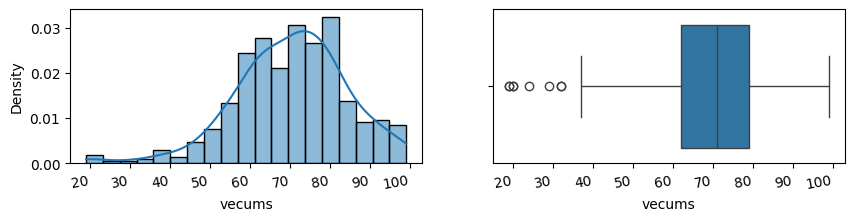


===== lidzPSKUS_timedelta_minutes =====
n: 461
n_unique: 193
Missing %: 0.07429718875502007%
MIN: 18. MAX: 466655
Median: 118.0
Mean: 15941.11
Trimmed mean: nan
Mode: 119
IQR: nan
5%: nan. 95%: nan
std: 64899.79
cv: 4.07 ➡️ Extreme Variability - highly chaotic relative to mean; interpret with caution
Skewness: 4.74 ➡️ Right-Skewed. Most data are "low"
Kurtosis: 22.95 ➡️ Leptokurtic. Many extreme "Black Swan" outliers


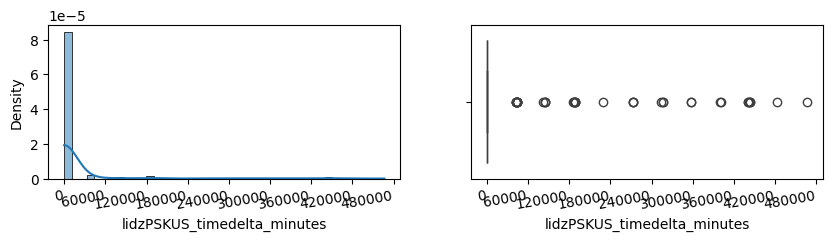


===== lidzizrakstisanai_timedelta_days =====
n: 394
n_unique: 82
Missing %: 0.20883534136546184%
MIN: 0. MAX: 306
Median: 9.0
Mean: 40.82
Trimmed mean: nan
Mode: 0
IQR: nan
5%: nan. 95%: nan
std: 71.52
cv: 1.75 ➡️ Extreme Variability - highly chaotic relative to mean; interpret with caution
Skewness: 2.17 ➡️ Right-Skewed. Most data are "low"
Kurtosis: 3.73 ➡️ Leptokurtic. Many extreme "Black Swan" outliers


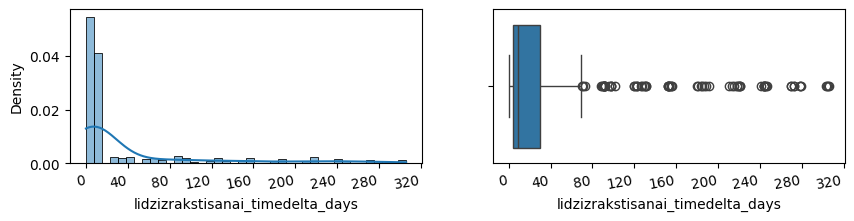

,column,n,n_unique,missing_%,max,min,median,mean,mode,std,cv,trimmed_mean,iqrange,p_5th,p_95th,skewness,kurtosis
0,vecums,498,65,0.00,99,19,71.0,70.291,"['65', '72', '76']",13.977,0.199,70.710,17.00,47.00,92.00,-0.51,0.95
1,lidzPSKUS_timedelta_minutes,461,193,0.07,466655,18,118.0,15941.111,['119'],64899.793,4.071,nan,nan,nan,nan,4.74,22.95
2,lidzizrakstisanai_timedelta_days,394,82,0.21,306,0,9.0,40.820,['0'],71.520,1.752,nan,nan,nan,nan,2.17,3.73


In [22]:
project.analyse_numerical()

----------------------
### categorical
----------------------


🚦🚦🚦 ============= CATEGORICAL ============= 🚦🚦🚦

===== nmpd_diag =====
n: 498
Unique count: 3
Cardinality: 3 ➡️ Very low ➡️ Ideal for standard one-hot|tree models
missing_pct: 0.00%
First MODE: I63.9
Proportion of MODE: 52.81%
second_mode: I64
second_mode_pct: 27.71%
rarest: G45.9: 19.48%
max_class_imbalance: 1.91
Imbalance ratio: 1.91 ➡️ Mild dominance of the top class ➡️ Usually fine, just monitor minority performance
median_category: <NA>
Entropy: 1.46 ➡️ Low Diversity ➡️ Usually binary or heavily skewed (e.g., Gender, Yes/No) ➡️ best action --> Keep. Best for root nodes in decision trees
Balance: 0.92 ➡️ Near-Uniform Spread ➡️ Values are distributed almost equally. Check whether this reflects true diversity or fragmented noise / ID-like categories


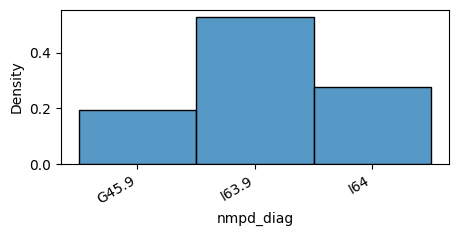


===== izrakstisanas_diag =====
n: 498
Unique count: 16
Cardinality: 16 ➡️ Moderate ➡️ Usually fine; watch for sparse rare levels
missing_pct: 0.00%
First MODE: G40.9
Proportion of MODE: 9.64%
second_mode: I61.9
second_mode_pct: 9.44%
rarest: N39.0: 3.01%
max_class_imbalance: 1.02
Imbalance ratio: 1.02 ➡️ Classes are similarly frequent ➡️ No special handling needed
median_category: <NA>
Entropy: 3.94 ➡️ High Chaos ➡️ Provides deep detail but can lead to overfitting ➡️ best action --> Group the 16 codes into 5-10 broader categories
Balance: 0.99 ➡️ Near-Uniform Spread ➡️ Values are distributed almost equally. Check whether this reflects true diversity or fragmented noise / ID-like categories


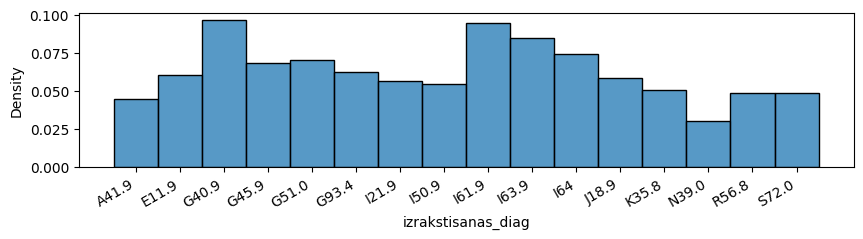


===== GKS =====
n: 438
Unique count: 13
Cardinality: 13 ➡️ Moderate ➡️ Usually fine; watch for sparse rare levels
missing_pct: 12.05%
First MODE: 12
Proportion of MODE: 14.61%
second_mode: 11
second_mode_pct: 11.19%
rarest: 6: 2.51%
max_class_imbalance: 1.31
Imbalance ratio: 1.31 ➡️ Classes are similarly frequent ➡️ No special handling needed
median_category: 11
Entropy: 3.55 ➡️ High Chaos ➡️ Provides deep detail but can lead to overfitting ➡️ best action --> Group the 13 codes into 5-10 broader categories
Balance: 0.96 ➡️ Near-Uniform Spread ➡️ Values are distributed almost equally. Check whether this reflects true diversity or fragmented noise / ID-like categories


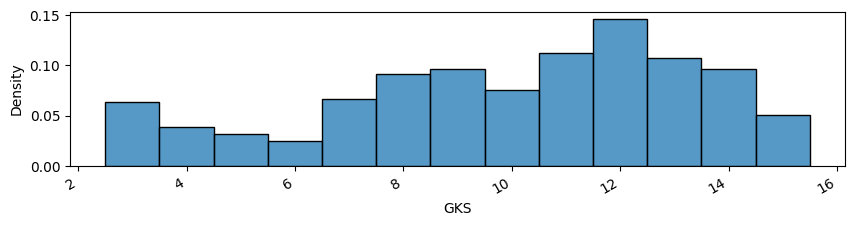


===== FastTest =====
n: 416
Unique count: 4
Cardinality: 4 ➡️ Very low ➡️ Ideal for standard one-hot|tree models
missing_pct: 16.47%
First MODE: 1
Proportion of MODE: 26.92%
second_mode: 4
second_mode_pct: 24.76%
rarest: 2: 24.04%
max_class_imbalance: 1.09
Imbalance ratio: 1.09 ➡️ Classes are similarly frequent ➡️ No special handling needed
median_category: 3
Entropy: 2.00 ➡️ The Sweet Spot ➡️ Healthy clinical variety ➡️ best action --> GOLDEN. This is the best for ML
Balance: 1.00 ➡️ Near-Uniform Spread ➡️ Values are distributed almost equally. Check whether this reflects true diversity or fragmented noise / ID-like categories


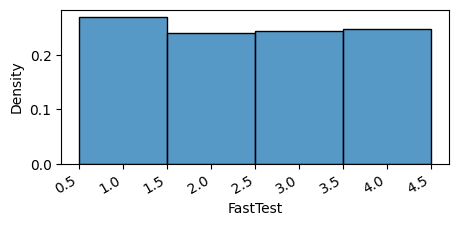


===== discharged_how =====
n: 498
Unique count: 4
Cardinality: 4 ➡️ Very low ➡️ Ideal for standard one-hot|tree models
missing_pct: 0.00%
First MODE: Discharged home
Proportion of MODE: 44.78%
second_mode: Continues treatment
second_mode_pct: 28.71%
rarest: Died in hospital: 8.03%
max_class_imbalance: 1.56
Imbalance ratio: 1.56 ➡️ Mild dominance of the top class ➡️ Usually fine, just monitor minority performance
median_category: <NA>
Entropy: 1.78 ➡️ The Sweet Spot ➡️ Healthy clinical variety ➡️ best action --> GOLDEN. This is the best for ML
Balance: 0.89 ➡️ Broad Diversity ➡️ Rich spread across categories. Usually keep; review for fragmentation if many categories are clinically tiny


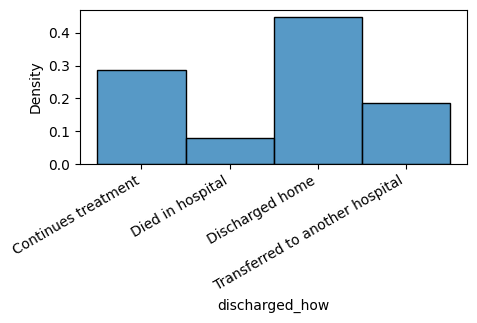


===== izsaukuma_laiks_hour =====
n: 498
Unique count: 24
Cardinality: 24 ➡️ High ➡️ Consider grouping rare levels or using target|impact encoding
missing_pct: 0.00%
First MODE: 3
Proportion of MODE: 5.62%
second_mode: 23
second_mode_pct: 5.42%
rarest: 21: 2.81%
max_class_imbalance: 1.04
Imbalance ratio: 1.04 ➡️ Classes are similarly frequent ➡️ No special handling needed
median_category: 12
Entropy: 4.56 ➡️ High Chaos ➡️ Provides deep detail but can lead to overfitting ➡️ best action --> Group the 24 codes into 5-10 broader categories
Balance: 0.99 ➡️ Near-Uniform Spread ➡️ Values are distributed almost equally. Check whether this reflects true diversity or fragmented noise / ID-like categories


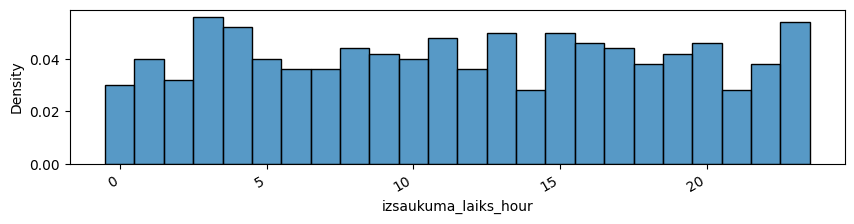


===== izsaukuma_laiks_dow =====
n: 498
Unique count: 7
Cardinality: 7 ➡️ Moderate ➡️ Usually fine; watch for sparse rare levels
missing_pct: 0.00%
First MODE: Tuesday
Proportion of MODE: 17.07%
second_mode: Monday
second_mode_pct: 15.26%
rarest: Saturday: 11.45%
max_class_imbalance: 1.12
Imbalance ratio: 1.12 ➡️ Classes are similarly frequent ➡️ No special handling needed
median_category: Thursday
Entropy: 2.80 ➡️ The Sweet Spot ➡️ Healthy clinical variety ➡️ best action --> GOLDEN. This is the best for ML
Balance: 1.00 ➡️ Near-Uniform Spread ➡️ Values are distributed almost equally. Check whether this reflects true diversity or fragmented noise / ID-like categories


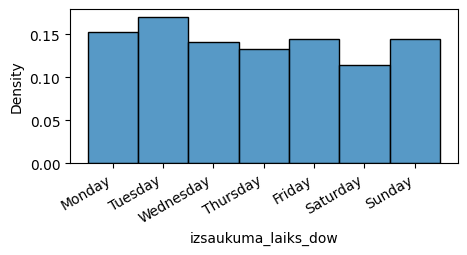


===== izsaukuma_laiks_month_name =====
n: 498
Unique count: 12
Cardinality: 12 ➡️ Moderate ➡️ Usually fine; watch for sparse rare levels
missing_pct: 0.00%
First MODE: October
Proportion of MODE: 11.65%
second_mode: May
second_mode_pct: 10.44%
rarest: November: 6.02%
max_class_imbalance: 1.12
Imbalance ratio: 1.12 ➡️ Classes are similarly frequent ➡️ No special handling needed
median_category: June
Entropy: 3.56 ➡️ High Chaos ➡️ Provides deep detail but can lead to overfitting ➡️ best action --> Group the 12 codes into 5-10 broader categories
Balance: 0.99 ➡️ Near-Uniform Spread ➡️ Values are distributed almost equally. Check whether this reflects true diversity or fragmented noise / ID-like categories


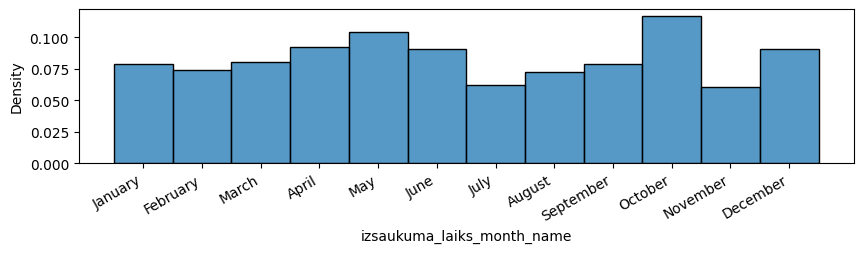

,col_name,n,n_unique,missing_pct,first_mode,second_mode,rarest,first_mode_pct,second_mode_pct,max_class_imbalance,median_category,balance,entropy_bin
0,nmpd_diag,498,3,0.00,I63.9,I64,G45.9: 19.48%,52.81,27.71,1.91,,0.92,1.46
1,izrakstisanas_diag,498,16,0.00,G40.9,I61.9,N39.0: 3.01%,9.64,9.44,1.02,,0.99,3.94
2,GKS,438,13,12.05,12,11,6: 2.51%,14.61,11.19,1.31,11,0.96,3.55
3,FastTest,416,4,16.47,1,4,2: 24.04%,26.92,24.76,1.09,3,1.00,2.00
4,discharged_how,498,4,0.00,Discharged home,Continues treatment,Died in hospital: 8.03%,44.78,28.71,1.56,,0.89,1.78
5,izsaukuma_laiks_hour,498,24,0.00,3,23,21: 2.81%,5.62,5.42,1.04,12,0.99,4.56
6,izsaukuma_laiks_dow,498,7,0.00,Tuesday,Monday,Saturday: 11.45%,17.07,15.26,1.12,Thursday,1.00,2.80
7,izsaukuma_laiks_month_name,498,12,0.00,October,May,November: 6.02%,11.65,10.44,1.12,June,0.99,3.56


In [23]:
project.analyse_categorical()

----------------------
### binary
----------------------


🚦🚦🚦 ================ BINARY =============== 🚦🚦🚦

===== dzimums =====
n: 498
Missing %: 0.00%
p1 (sieviete): 0.52
p0 (vīrietis): 0.48
MODE: equal
MODE %: 47.79%
Balance: 0.96 ➡️ Healthy Balance - great for modeling
Entropy:1.00 ➡️ High entropy - close to 50/50. Maximally informative for splits; great for ML


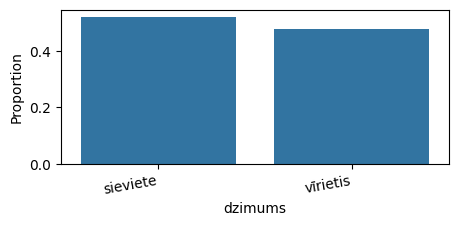


===== izsaukuma_laiks_workday_bool =====
n: 498
Missing %: 0.00%
p1 (True): 0.74
p0 (False): 0.26
MODE: True
MODE %: 74.10%
Balance: 0.52 ➡️ Moderate Imbalance - generally fine, but watch rare class
Entropy:0.83 ➡️ High entropy - close to 50/50. Maximally informative for splits; great for ML


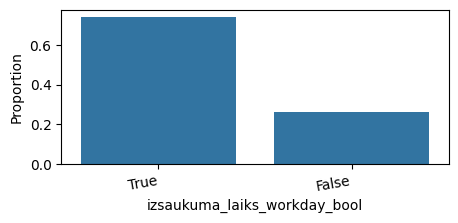


===== GKS_missing =====
n: 498
p1 (False): 0.88
p0 (True): 0.12
MODE: False
MODE %: 87.95%
Balance: 0.24 ➡️ Heavy Imbalance - rare positives/negatives. Handle with care
Entropy:0.53 ➡️ Moderate entropy - decent mix, but still some skew. Often fine for modeling


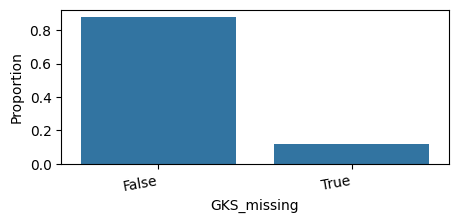


===== FastTest_missing =====
n: 498
p1 (False): 0.84
p0 (True): 0.16
MODE: False
MODE %: 83.53%
Balance: 0.33 ➡️ Moderate Imbalance - generally fine, but watch rare class
Entropy:0.65 ➡️ Moderate entropy - decent mix, but still some skew. Often fine for modeling


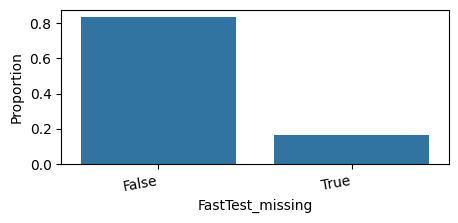

,column,n,missing_pct,p1,p0,mode,mode_pct,balance,entropy_bin
0,dzimums,498,0.000,0.522,0.478,equal,47.791,0.956,0.999
1,izsaukuma_laiks_workday_bool,498,0.000,0.741,0.259,True,74.096,0.518,0.825
2,GKS_missing,498,,0.880,0.120,False,87.952,0.241,0.531
3,FastTest_missing,498,,0.835,0.165,False,83.534,0.329,0.645


In [24]:
project.analyse_binary()

----------------------
### Export all the tables
----------------------

In [25]:
export = True
project.export_all_overviews(export)

✅ Successful EXPORT of all DDA overviews

✅ Folder: ylivertainen/reports/tables/
✅ FORMAT: pickle

✅ Numerical DDA Overview: (numerical_DDA_overview)any_cerebrovascular_match_binary
✅ Categorical DDA Overview: (categorical_DDA_overview)any_cerebrovascular_match_binary
✅ Binary DDA Overview: (binary_DDA_overview)any_cerebrovascular_match_binary


----------------------
## **PREPARE FOR EDA**
----------------------

In [26]:
post_DDA_df, task_name = project.prepare_for_EDA()

══════════════════════════════════════════════════════════════════════
🧠 DDA STAGE COMPLETE — BRAIN MAP LOCKED IN
──────────────────────────────────────────────────────────────────────
✔ DDA FRAME READY FOR EDA ANGIO SUITE
   Shape         : 498 rows x 19 cols
   Remaining NaNs: 283 cells (2.99%)
   Contents      : variable summaries, distributions, missingness map — all scrubbed and labeled.

→ Next hop: feed `post_DDA_df` straight into the EDA class for full association hunting and leakage checks.


,row_id,target,nmpd_diag,izrakstisanas_diag,vecums,dzimums,GKS,FastTest,discharged_how,patient_card_no,lidzPSKUS_timedelta_minutes,lidzizrakstisanai_timedelta_days,izsaukuma_laiks_hour,izsaukuma_laiks_dow,izsaukuma_laiks_workday_bool,izsaukuma_laiks_month_name,GKS_missing,FastTest_missing,task_name
0,0,False,I64,J18.9,69,sieviete,3,2,Transferred to another hospital,K202400001,213164,29,3,Tuesday,True,June,False,False,any_cerebrovascular_match_binary
1,1,True,G45.9,G45.9,70,sieviete,15,NaN,Discharged home,K202500002,76,<NA>,16,Monday,True,October,False,True,any_cerebrovascular_match_binary
2,2,False,G45.9,K35.8,80,vīrietis,12,3,Discharged home,K202500003,53,8,1,Sunday,False,December,False,False,any_cerebrovascular_match_binary
3,3,True,I63.9,I64,91,sieviete,8,4,Continues treatment,K202500004,45,11,14,Saturday,False,January,False,False,any_cerebrovascular_match_binary
4,4,False,I63.9,G51.0,68,vīrietis,10,3,Transferred to another hospital,K202400005,184,12,22,Saturday,False,October,False,False,any_cerebrovascular_match_binary


-------------
# 📊🎨 **YLIVERTAINEN EDA** 🎨📊
-------------

----------------------
## **STUDY AIM AND QUESTIONS**
----------------------

-------------------------------------
### **COHORT DEFINITION**
- **Source:** PSKUS
- **Time window:** Year 2022-2023
- **Row:** 1 unique patient case
-------------------------------------
### **KEY INCLUSION SCOPE**
- "NMP pamata diagnoze": I63.9, I64, G45.9
- "Izrakstīšanas diagnozes kods"
-------------------------------------
### **STUDY AIM**
- **EXPLORE:** 
    - "NMP pamata diagnoze" vs "Izrakstīšanas diagnozes kods"
- **FIND:** 
    - Agreement/Mismatch
- **ADDITIONAL AIMS:**
    - Identify predictors associated with diagnostic agreement or mismatch
-------------------------------------
### **STUDY CONTEXT**

<p>This notebook explores agreement between prehospital stroke-related diagnosis and discharge diagnosis in PSKUS 2022-2023 data in patients.
<p>The goal is to understand how often prehospital diagnosis aligns with hospital discharge diagnosis and which patient or process factors may be associated with disagreement

-------------------------------------

----------------------
## **LOAD DATASET**
----------------------

In [27]:
project = YlivertainenEDA(root, post_DDA_df, metadata)
project.EDA.head(5)

,row_id,target,nmpd_diag,izrakstisanas_diag,vecums,dzimums,GKS,FastTest,discharged_how,patient_card_no,lidzPSKUS_timedelta_minutes,lidzizrakstisanai_timedelta_days,izsaukuma_laiks_hour,izsaukuma_laiks_dow,izsaukuma_laiks_workday_bool,izsaukuma_laiks_month_name,GKS_missing,FastTest_missing,task_name
0,0,False,I64,J18.9,69,sieviete,3,2,Transferred to another hospital,K202400001,213164,29,3,Tuesday,True,June,False,False,any_cerebrovascular_match_binary
1,1,True,G45.9,G45.9,70,sieviete,15,NaN,Discharged home,K202500002,76,<NA>,16,Monday,True,October,False,True,any_cerebrovascular_match_binary
2,2,False,G45.9,K35.8,80,vīrietis,12,3,Discharged home,K202500003,53,8,1,Sunday,False,December,False,False,any_cerebrovascular_match_binary
3,3,True,I63.9,I64,91,sieviete,8,4,Continues treatment,K202500004,45,11,14,Saturday,False,January,False,False,any_cerebrovascular_match_binary
4,4,False,I63.9,G51.0,68,vīrietis,10,3,Transferred to another hospital,K202400005,184,12,22,Saturday,False,October,False,False,any_cerebrovascular_match_binary


----------------------
## **LOAD THE VARIABLES**
----------------------

In [28]:
project.EDA.columns

Index(['row_id', 'target', 'nmpd_diag', 'izrakstisanas_diag', 'vecums',
       'dzimums', 'GKS', 'FastTest', 'discharged_how', 'patient_card_no',
       'lidzPSKUS_timedelta_minutes', 'lidzizrakstisanai_timedelta_days',
       'izsaukuma_laiks_hour', 'izsaukuma_laiks_dow',
       'izsaukuma_laiks_workday_bool', 'izsaukuma_laiks_month_name',
       'GKS_missing', 'FastTest_missing', 'task_name'],
      dtype='str')

In [29]:
project.EDA.dtypes

row_id                                 int64
target                               boolean
nmpd_diag                           category
izrakstisanas_diag                  category
vecums                                 int64
dzimums                             category
GKS                                 category
FastTest                            category
discharged_how                      category
patient_card_no                     category
lidzPSKUS_timedelta_minutes            Int64
lidzizrakstisanai_timedelta_days       Int64
izsaukuma_laiks_hour                category
izsaukuma_laiks_dow                 category
izsaukuma_laiks_workday_bool            bool
izsaukuma_laiks_month_name          category
GKS_missing                             bool
FastTest_missing                        bool
task_name                                str
dtype: object

----------------------
### Whitelist columns for analysis
----------------------

In [30]:
# ============ Defining test_col, reference_col, features. Choosing columns to remain ============
predictors = ['nmpd_diag', 'vecums', 'dzimums',
              'GKS', 'FastTest',
              'discharged_how',
              'lidzPSKUS_timedelta_minutes', 'lidzizrakstisanai_timedelta_days',
              'izsaukuma_laiks_hour', 'izsaukuma_laiks_dow', 'izsaukuma_laiks_workday_bool', 'izsaukuma_laiks_month_name',
              'GKS_missing', 'FastTest_missing']
numerical_continuous = ['vecums']

project.whitelist_columns(predictors, numerical_continuous)

✅ All cols classified 
===== Main variables =====
Target: any_cerebrovascular_match_binary AS "target" (boolean)
Predictors: 14 total
- Numerical Continuous: vecums
- Binary: izsaukuma_laiks_workday_bool, GKS_missing, FastTest_missing
- Categorical Nominal: nmpd_diag, dzimums, discharged_how
- Categorical Ordinal: GKS, FastTest, izsaukuma_laiks_hour, izsaukuma_laiks_dow, izsaukuma_laiks_month_name
- Time To Event: lidzPSKUS_timedelta_minutes, lidzizrakstisanai_timedelta_days


In [31]:
project.EDA.head()

,target,vecums,izsaukuma_laiks_workday_bool,GKS_missing,FastTest_missing,nmpd_diag,dzimums,discharged_how,GKS,FastTest,izsaukuma_laiks_hour,izsaukuma_laiks_dow,izsaukuma_laiks_month_name,lidzPSKUS_timedelta_minutes,lidzizrakstisanai_timedelta_days,row_id
0,False,69,True,False,False,I64,sieviete,Transferred to another hospital,3,2,3,Tuesday,June,213164,29,0
1,True,70,True,False,True,G45.9,sieviete,Discharged home,15,NaN,16,Monday,October,76,<NA>,1
2,False,80,False,False,False,G45.9,vīrietis,Discharged home,12,3,1,Sunday,December,53,8,2
3,True,91,False,False,False,I63.9,sieviete,Continues treatment,8,4,14,Saturday,January,45,11,3
4,False,68,False,False,False,I63.9,vīrietis,Transferred to another hospital,10,3,22,Saturday,October,184,12,4


----------------------
## **ASSOCIATIONS & FEATURE DECISIONS**
----------------------

In [32]:
if 'tia_match_binary' in project.task_name:
    leakage_vars = {'nmpd_diag',}
else:
    leakage_vars = None         # list of str
missingness_dict = None         # pd.DataFrame([{"column_name": "nmpd_diag", "missingness_type": "missing", "inferred_type": "categorical"}, {...}])
redundancy_pairs = None         # pd.DataFrame([{"var_a": "age", "var_b": "age_years", "preferred_keep": "age"}, {...}])

In [33]:
project.build_associations_table(leakage_vars)

,analysis_col,predictor_col,analysis_type,predictor_type,pair_type,n_used,analysis_excluded_n,predictor_missing_n,status,note,test_name,test_stat,p_value,effect_size_name,effect_size,p_value_note,leakage_flag
0,target,vecums,binary,continuous,predictor_target,498,0,0,ok,<NA>,point_biserial,0.053405,0.23419,r,0.053405,ns,False
1,target,izsaukuma_laiks_workday_bool,binary,binary,predictor_target,498,0,0,ok,<NA>,chi2,0.788586,0.374528,cramers_v,0.039793,ns,False
2,target,GKS_missing,binary,binary,predictor_target,498,0,0,ok,<NA>,chi2,0.129958,0.718476,cramers_v,0.016154,ns,False
3,target,FastTest_missing,binary,binary,predictor_target,498,0,0,ok,<NA>,chi2,0.047846,0.826854,cramers_v,0.009802,ns,False
4,target,nmpd_diag,binary,categorical_nominal,predictor_target,498,0,0,ok,<NA>,chi2,0.831563,0.659824,cramers_v,0.040863,ns,False
5,target,dzimums,binary,categorical_nominal,predictor_target,498,0,0,ok,<NA>,chi2,0.142629,0.705681,cramers_v,0.016923,ns,False
6,target,discharged_how,binary,categorical_nominal,predictor_target,498,0,0,ok,<NA>,chi2,1.452773,0.693212,cramers_v,0.054011,ns,False
7,target,GKS,binary,categorical_ordinal,predictor_target,438,0,60,ok,<NA>,chi2,13.891483,0.307692,cramers_v,0.178089,ns,False
8,target,FastTest,binary,categorical_ordinal,predictor_target,416,0,82,ok,<NA>,chi2,1.838121,0.606675,cramers_v,0.066472,ns,False
9,target,izsaukuma_laiks_hour,binary,categorical_ordinal,predictor_target,498,0,0,ok,<NA>,chi2,16.547562,0.830847,cramers_v,0.182286,ns,False


In [34]:
feature_decisions_df = project.build_feature_decisions_table(missingness_dict, leakage_vars, redundancy_pairs)

,column_name,role,dtype,inferred_type,missing_pct,drop_reason,action,missing_action,notes
0,target,target,boolean,unknown,0.0,,keep,no_missing,<NA>
1,vecums,predictor,int64,continuous,0.0,,keep,no_missing,<NA>
2,izsaukuma_laiks_workday_bool,predictor,bool,binary,0.0,,keep,no_missing,<NA>
3,nmpd_diag,predictor,category,categorical_nominal,0.0,,keep,no_missing,<NA>
4,dzimums,predictor,category,categorical_nominal,0.0,,keep,no_missing,<NA>
5,discharged_how,predictor,category,categorical_nominal,0.0,,keep,no_missing,<NA>
6,GKS,predictor,category,categorical_ordinal,12.048193,,keep,simple_impute,<NA>
7,FastTest,predictor,category,categorical_ordinal,16.465863,,keep,simple_impute,<NA>
8,izsaukuma_laiks_hour,predictor,category,categorical_ordinal,0.0,,keep,no_missing,<NA>
9,izsaukuma_laiks_dow,predictor,category,categorical_ordinal,0.0,,keep,no_missing,<NA>


----------------------
### EXPORT TABLES
----------------------

In [35]:
project.export_both_tables(export=True)

✅ Successful EXPORT of feature_decisions_table
✅ Folder: ylivertainen/reports/tables/
✅ Feature Decisions Table: (feature_decisions_table)any_cerebrovascular_match_binary
✅ Associations Table: (associations_table)any_cerebrovascular_match_binary
✅ FORMAT: pickle



----------------------
## **PREPARE FOR PREDICTIVE ANALYSIS**
----------------------

In [36]:
post_EDA_df, task_name = project.prepare_EDA()

══════════════════════════════════════════════════════════════════════
🧠 EDA COMPLETE — FULL BRAIN ANGIOGRAM ACQUIRED
──────────────────────────────────────────────────────────────────────
✔ EDA FRAME ONLINE FOR DECISION-MAKING
   Shape         : 498 rows x 16 cols
   Remaining NaNs: 283 cells (3.55%)
   Contents      : associations mapped, redundancy flagged, leakage suspects tagged.

→ Neurosurgical note: this is the point where others stop and 
                        you push through — 
                          turn this map into hard feature decisions and a clean model frame.


,target,vecums,izsaukuma_laiks_workday_bool,GKS_missing,FastTest_missing,nmpd_diag,dzimums,discharged_how,GKS,FastTest,izsaukuma_laiks_hour,izsaukuma_laiks_dow,izsaukuma_laiks_month_name,lidzPSKUS_timedelta_minutes,lidzizrakstisanai_timedelta_days,row_id
0,False,69,True,False,False,I64,sieviete,Transferred to another hospital,3,2,3,Tuesday,June,213164,29,0
1,True,70,True,False,True,G45.9,sieviete,Discharged home,15,NaN,16,Monday,October,76,<NA>,1
2,False,80,False,False,False,G45.9,vīrietis,Discharged home,12,3,1,Sunday,December,53,8,2
3,True,91,False,False,False,I63.9,sieviete,Continues treatment,8,4,14,Saturday,January,45,11,3
4,False,68,False,False,False,I63.9,vīrietis,Transferred to another hospital,10,3,22,Saturday,October,184,12,4


-------------
# 🔮🔮🔮 **YLIVERTAINEN PREDICTIVE** 🔮🔮🔮
-------------

In [37]:
export = True

In [38]:
feature_decisions_df
df_model, X, y = build_model_frame(post_cohort_df, feature_decisions_df, metadata)
df_model = export_model_frame(root, X, y, metadata, export)

,column_name,role,dtype,inferred_type,missing_pct,drop_reason,action,missing_action,notes
0,target,target,boolean,unknown,0.000000,,keep,no_missing,
1,vecums,predictor,int64,continuous,0.000000,,keep,no_missing,
2,izsaukuma_laiks_workday_bool,predictor,bool,binary,0.000000,,keep,no_missing,
3,nmpd_diag,predictor,category,categorical_nominal,0.000000,,keep,no_missing,
4,dzimums,predictor,category,categorical_nominal,0.000000,,keep,no_missing,
5,discharged_how,predictor,category,categorical_nominal,0.000000,,keep,no_missing,
6,GKS,predictor,category,categorical_ordinal,12.048193,,keep,simple_impute,
7,FastTest,predictor,category,categorical_ordinal,16.465863,,keep,simple_impute,
8,izsaukuma_laiks_hour,predictor,category,categorical_ordinal,0.000000,,keep,no_missing,
9,izsaukuma_laiks_dow,predictor,category,categorical_ordinal,0.000000,,keep,no_missing,


Feature Decisions DF: any_cerebrovascular_match_binary
Target Column: target
Viable Predictors: 12
continuous: "vecums"
binary: "izsaukuma_laiks_workday_bool"
categorical_nominal: "nmpd_diag", "dzimums", "discharged_how"
categorical_ordinal: "GKS", "FastTest", "izsaukuma_laiks_hour", "izsaukuma_laiks_dow", "izsaukuma_laiks_month_name"
time_to_event: "lidzPSKUS_timedelta_minutes", "lidzizrakstisanai_timedelta_days"
Non-viable predictors: 

dropping bad cols...
running simple impute...
-> "GKS" is categorical so using mode
GKS NaN-count: 12.05%->0.0%
-> "FastTest" is categorical so using mode
FastTest NaN-count: 16.47%->0.0%
-> "lidzPSKUS_timedelta_minutes" is non-categorical so using median
lidzPSKUS_timedelta_minutes NaN-count: 7.43%->0.0%
running advanced impute...
══════════════════════════════════════════════════════════════════════
🧠 MODEL FRAME ONLINE
──────────────────────────────────────────────────────────────────────
✔ CLEAN (X, y) EXTRACTED FOR: any_cerebrovascular_match_bina

,vecums,izsaukuma_laiks_workday_bool,nmpd_diag,dzimums,discharged_how,GKS,FastTest,izsaukuma_laiks_hour,izsaukuma_laiks_dow,izsaukuma_laiks_month_name,lidzPSKUS_timedelta_minutes,lidzizrakstisanai_timedelta_days,target
0,69,True,I64,sieviete,Transferred to another hospital,3,2,3,Tuesday,June,213164,29,False
1,70,True,G45.9,sieviete,Discharged home,15,1,16,Monday,October,76,40,True
2,80,False,G45.9,vīrietis,Discharged home,12,3,1,Sunday,December,53,8,False
3,91,False,I63.9,sieviete,Continues treatment,8,4,14,Saturday,January,45,11,True
4,68,False,I63.9,vīrietis,Transferred to another hospital,10,3,22,Saturday,October,184,12,False


✔ Saved model frame to: C:\dev\TheLibraryOfCode\YlivertainenBadDataCraniotomy\ylivertainen\data\processed\(model_frame)any_cerebrovascular_match_binary.pickle


-------------
#  **FINAL SUMMARY** 
-------------

In [39]:
# ===== FINAL SUMMARY CODE =====
df_rows = df_model.shape[0]
df_cols = df_model.shape[1]

prevalence = df_model["target"].mean()
vc = df_model.target.value_counts()

mask = (feature_decisions_df["action"] == "keep") & (feature_decisions_df["role"] == "predictor")
pred_n = feature_decisions_df[mask]["column_name"].count()

mask = feature_decisions_df["drop_reason"] == "leakage"
leak_excl = feature_decisions_df[feature_decisions_df["notes"].notna() & mask][
    ["column_name", "notes", "action"]
]

mask = feature_decisions_df["notes"] != "identifier_column"
warnings_table = feature_decisions_df[feature_decisions_df["notes"].notna() & mask][
    ["column_name", "notes"]
]

vc_table = vc.reset_index()
vc_table.columns = ["class", "n"]

pred_lines = []
for inf_type in sorted(feature_decisions_df.inferred_type.unique(), key=str):
    cols = feature_decisions_df[
        (feature_decisions_df.inferred_type == inf_type)
        & (feature_decisions_df.role == "predictor")
        & (feature_decisions_df.action == "keep")
    ].column_name.tolist()
    if cols:
        cols_fmt = ", ".join(f"`{c}`" for c in cols)
        pred_lines.append(f"- **{inf_type}:** {cols_fmt}")
pred_md = "\n".join(pred_lines) if pred_lines else "*No predictors listed.*"

_positive = metadata.get("positive_class", "—") if "metadata" in globals() else "—"

display(
    Markdown(
        f"""# 🧠 Final run summary

> *I would like to see the day when somebody would be appointed surgeon somewhere because of his caring, his belief in the patient, and his love of his fellow man.* — Harvey Cushing

**Task:** `{task_name}` · **Positive class:** `{_positive}`

---
"""
    )
)

display(
    Markdown(
        f"""### 📊 Cohort size

- **Rows:** {df_rows:,}
- **Columns in `df_model`:** {df_cols} *(includes target, IDs, and features)*

---
"""
    )
)

display(
    Markdown(
        f"""### 🎯 Target prevalence

- **Positive rate:** {prevalence:.3f}

#### Class counts
"""
    )
)
display(vc_table)

display(Markdown("---\n### 🔬 Predictors kept\n"))
display(Markdown(f"- **Count:** {pred_n}\n"))
display(Markdown(pred_md))

display(Markdown("\n---\n### 🧪 Leakage exclusions\n"))
if len(leak_excl) == 0:
    display(Markdown("*No rows with notes.*"))
else:
    display(leak_excl)

display(Markdown("\n---\n### ⚠️ Main warnings\n"))
if len(warnings_table) == 0:
    display(Markdown("*No rows with notes.*"))
else:
    display(warnings_table)

# 🧠 Final run summary

> *I would like to see the day when somebody would be appointed surgeon somewhere because of his caring, his belief in the patient, and his love of his fellow man.* — Harvey Cushing

**Task:** `any_cerebrovascular_match_binary` · **Positive class:** `True`

---


### 📊 Cohort size

- **Rows:** 498
- **Columns in `df_model`:** 13 *(includes target, IDs, and features)*

---


### 🎯 Target prevalence

- **Positive rate:** 0.321

#### Class counts


,class,n
0,False,338
1,True,160


---
### 🔬 Predictors kept


...

- **binary:** `izsaukuma_laiks_workday_bool`
- **categorical_nominal:** `nmpd_diag`, `dzimums`, `discharged_how`
- **categorical_ordinal:** `GKS`, `FastTest`, `izsaukuma_laiks_hour`, `izsaukuma_laiks_dow`, `izsaukuma_laiks_month_name`
- **continuous:** `vecums`
- **time_to_event:** `lidzPSKUS_timedelta_minutes`, `lidzizrakstisanai_timedelta_days`


---
### 🧪 Leakage exclusions


*No rows with notes.*


---
### ⚠️ Main warnings


*No rows with notes.*